In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import(
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import os
import joblib


In [ ]:
df = pd.read_csv(r'../dataset/train.csv')

df.head()

,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,0,unhealthy,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female
1,1,at-risk,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other
2,2,unhealthy,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male
3,3,unhealthy,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female
4,4,at-risk,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,NaN,average,sedentary,NaN,male


In [3]:
x = df.drop("health_condition", axis=1)

y=df["health_condition"]

In [4]:
numerical_columns = x.select_dtypes(include=["int64", "float64"]).columns

for column in numerical_columns:
    x[column]=x[column].fillna(x[column].median()) 

In [5]:
categorical_columns = x.select_dtypes(include=["object"]).columns

for column in categorical_columns:
    x[column] = x[column].fillna(x[column].mode()[0])

C:\Users\udnrm\AppData\Local\Temp\ipykernel_3784\441477592.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = x.select_dtypes(include=["object"]).columns


In [6]:
x = pd.get_dummies(
    x, 
    drop_first=True,
     dtype=int
    )

In [7]:
x_train, x_valid, y_train, y_valid = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)



In [8]:
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_valid_scaled = scaler.transform(x_valid)

In [9]:
mlp_model = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation="relu",
    solver="adam",
    alpha=0.0001,
    batch_size=256,
    learning_rate="adaptive",
    max_iter=300,
    random_state=42,
    early_stopping=True
)

In [10]:
start = time.time()

mlp_model.fit(
    x_train_scaled,
    y_train
)

end = time.time()
print("Training Time:", round(end-start,2), "seconds")


Training Time: 164.41 seconds


In [11]:
y_pred = mlp_model.predict(x_valid_scaled)

96.40046950397773
89.86306597902684
              precision    recall  f1-score   support

     at-risk       0.96      0.99      0.98    118512
         fit       0.95      0.78      0.86      7961
   unhealthy       0.96      0.77      0.86     11545

    accuracy                           0.96    138018
   macro avg       0.96      0.85      0.90    138018
weighted avg       0.96      0.96      0.96    138018

[[117902    285    325]
 [  1717   6216     28]
 [  2598     15   8932]]


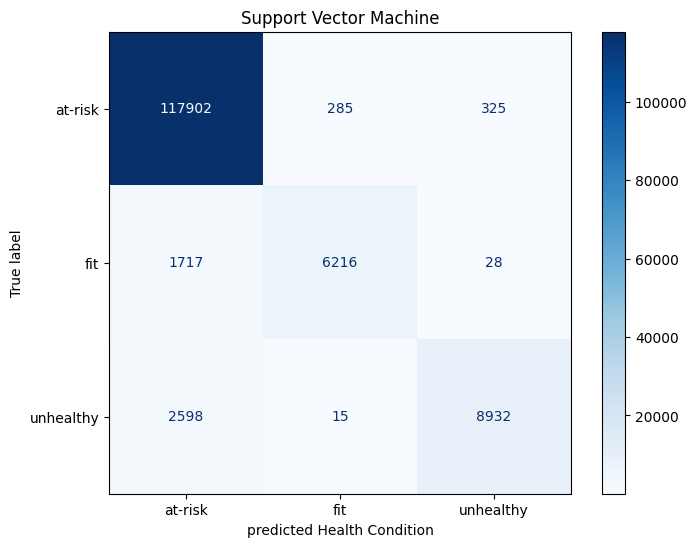

In [12]:
accuracy = accuracy_score(y_valid, y_pred)
print(accuracy*100
)

f1_score =f1_score(y_valid, y_pred, average="macro")
print(f1_score*100
)

print(classification_report(y_valid, y_pred))

cm = confusion_matrix(y_valid, y_pred)
print(cm)


fig, ax = plt.subplots(figsize=(8,6))

ConfusionMatrixDisplay.from_predictions(
    y_valid,
    y_pred,
    display_labels=mlp_model.classes_,
    cmap="Blues",
    ax=ax
)

plt.title("Support Vector Machine")
plt.xlabel("predicted Health Condition")
plt.show()

In [13]:
os.makedirs("models_mlp", exist_ok=True)

joblib.dump(mlp_model, "models_mlp/mlp_model.pkl")
joblib.dump(scaler, "models_mlp/scaler.pkl")
joblib.dump(x.columns.tolist(), "models_mlp/feature_names.pkl")

print("MLP artifacts saved!")

MLP artifacts saved!


In [ ]:

mlp_model = joblib.load("models_mlp/mlp_model.pkl")
scaler = joblib.load("models_mlp/scaler.pkl")
feature_names = joblib.load("models_mlp/feature_names.pkl")



test_df = pd.read_csv(r'../dataset/test.csv')

test_ids = test_df["id"]




numerical_columns = test_df.select_dtypes(
    include=["int64", "float64"]
).columns

for column in numerical_columns:
    test_df[column] = test_df[column].fillna(
        test_df[column].median()
    )


categorical_columns = test_df.select_dtypes(
    include=["object"]
).columns

for column in categorical_columns:
    test_df[column] = test_df[column].fillna(
        test_df[column].mode()[0]
    )


test_df = pd.get_dummies(
    test_df,
    drop_first=True,
    dtype=int
)


test_df = test_df.reindex(
    columns=feature_names,
    fill_value=0
)



test_scaled = scaler.transform(test_df)



predictions = mlp_model.predict(test_scaled)



submission = pd.DataFrame({
    "id": test_ids,
    "health_condition": predictions
})


os.makedirs("Submissions", exist_ok=True)

submission.to_csv(
    "Submissions/mlp_submission.csv",
    index=False
)


print("MLP submission created successfully!")
print(submission.head())
print(submission.shape)

C:\Users\udnrm\AppData\Local\Temp\ipykernel_3784\1461478772.py:24: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = test_df.select_dtypes(


MLP submission created successfully!
       id health_condition
0  690088        unhealthy
1  690089          at-risk
2  690090          at-risk
3  690091          at-risk
4  690092        unhealthy
(295753, 2)
